# Homework 3
### ASTR 324, Spring 2026, Ivezic, University of Washington

https://github.com/uw-astr-324/astr-324-s26


## Homework submission procedure: 

* You will be sending me your executed (with all the plots etc) *.ipynb files via email

* the Subject: line **must be** "astr-324-s26-FirstLast-HW?, where FirstLast is your first
and last name, and ? will be 1, 2, 3 or 4. 

* For example: astr-324-s26-ZeljkoIvezic-HW1

* I will be recognizing and downloading your submissions using a script. If you don't 
follow the above, your HW will not be recognized.

* Your homework email **must be sent** before Thursday class (that is, before 10am)
two weeks after that homework was assigned (e.g. HW1 will be available by the start of Thursday 
class on April 9, and will be due by 10am on April 23).

 

## Problem 1

Use **PyMC** to fit this function to the provided dataset (see below): 
$y(x) = A * x * np.cos(B*x) + C$. Show plots with
the progress of chains, the corner plot, and a plot that shows data (with uncertainties for both x and y axis)
and the best-fit model. What are the values of the best-fit model parameters (give 95% credible intervals)? 


## Problem 2

Use **emcee** to fit two functions to the provided dataset (see below).

**Function 1:** 5-th order polynomial, $y(x) = \sum_{j=0}^5 c_j \, x^j$.

**Function 2:** $y(x) = A * x * np.cos(B*x) + C$. 

Show plots with
the progress of chains and the corner plots for both models, and a plot that shows data (with uncertainties for y axis) and both best fit models. Which model is a better description of provided data? How strong is the evidence? 


## Problem 3

Apply Bayesian Blocks Algorithm to period distribution of LINEAR variable stars (see below) and
compare the result to classical (Knuth's) uniform bin width histogram.
Plot histograms on both linear and log scale. 

## Problem 4

These questions are similar to those that you will be asked on the final exam. Please answer each one with 1-3 sentences. 

* What does Markov Chain Monte Carlo method do?  

* What can Metropolis-Hastings algorithm do? 

* What is Bayesian Blocks algorithm useful for? How is it different from Knuth's histogram? 

# Homework 3: Solutions

### Some useful definitions and functions

In [1]:
import numpy as np 
from matplotlib import pyplot as plt
from scipy.stats import norm

# MCMC library
import pymc as pm
# analysis and visualization helper for pymc
import arviz as az

# here we are using emcee
import emcee 
import corner 

%matplotlib inline

Write your solutions below...

## Problem 1

Use **PyMC** to fit this function to the provided dataset (see below): 
$y(x) = A * x * np.cos(B*x) + C$. Show plots with
the progress of chains, the corner plot, and a plot that shows data (with uncertainties for both x and y axis)
and the best-fit model. What are the values of the best-fit model parameters (give 95% credible intervals)? 

### dataset to fit:

In [2]:
xObs = np.array([0.0, 0.26315789, 0.52631579, 0.78947368, 1.05263158, 1.31578947, 1.57894737, 1.84210526, 2.10526316, 2.36842105, 2.63157895, 2.89473684, 3.15789474, 3.42105263, 3.68421053, 3.94736842, 4.21052632, 4.47368421, 4.73684211, 5.0])
yObs = np.array([-0.01519999,  0.32530142,  0.62251935,  0.53022095,  0.49561467, 0.50552021,  0.07149746, -0.54528213, -1.01273784, -1.74602254, -2.34787813, -2.78038444, -3.36781022, -3.47795891, -3.21682447, -2.84510209, -1.99096649, -1.1576002 , -0.03944155,  1.57943597])
xErr = np.array([0.10993428, 0.09723471, 0.11295377, 0.1304606 , 0.09531693, 0.09531726, 0.13158426, 0.11534869, 0.09061051, 0.1108512, 0.09073165, 0.0906854 , 0.10483925, 0.0617344 , 0.06550164, 0.08875425, 0.07974338, 0.10628495, 0.08183952, 0.07175393])
yErr = np.array([0.10993428, 0.09723471, 0.11295377, 0.1304606 , 0.09531693, 0.09531726, 0.13158426, 0.11534869, 0.09061051, 0.1108512, 0.09073165, 0.0906854 , 0.10483925, 0.0617344 , 0.06550164, 0.08875425, 0.07974338, 0.10628495, 0.08183952, 0.07175393])

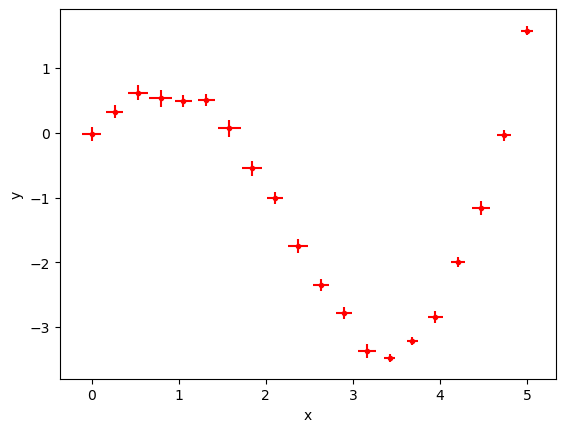

In [3]:
# let's take a look at the data  
ax = plt.figure().add_subplot(111)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.errorbar(xObs, yObs, xerr=xErr, yerr=yErr, color='r', marker='.', ls='None', label='data')
plt.show() 

In [4]:
def my_model(x, A, B, C):
    return A * x * pm.math.cos(B * x) + C

def my_model_np(x, A, B, C):
    return A * x * np.cos(B * x) + C  

# three points to make:
# 1) note setting of the priors (for a, b, c and d)
# 2) note how error in x is handled with a latent variable
def MCMC_fit(xObs, yObs, xErr, yErr, doXerror=True, draws=1000, tune=200):

    with pm.Model() as model:
        # 1) priors
        a = pm.Uniform('a', 0.5, 1.5)
        b = pm.Uniform('b', 0.5, 1.5)
        c = pm.Uniform('c', -.2, .2)

        # 2) latent variable for x-error
        if doXerror:
            xLatent = pm.Normal('x', mu=xObs, sigma=xErr, shape=xObs.shape)
        else:
            xLatent = xObs

        # 3) likelihood
        mu = my_model(xLatent, a, b, c)
        y = pm.Normal('y', mu=mu, sigma=yErr, observed=yObs)

        # sampling (modern PyMC handles NUTS automatically)
        idata = pm.sample(draws=draws, tune=tune, random_seed=123,
                          return_inferencedata=True, target_accept = 0.97)

    return idata

In [5]:
# obtain MCMC results
traces = MCMC_fit(xObs, yObs, xErr, yErr, doXerror=True, draws=5000, tune=5000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, c, x]


Output()

Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 21 seconds.


In [6]:
# compute summary statistics
summary = az.summary(traces, hdi_prob=0.95)
# best-fit parameters (posterior means)
bf = summary["mean"]

<Figure size 640x480 with 0 Axes>

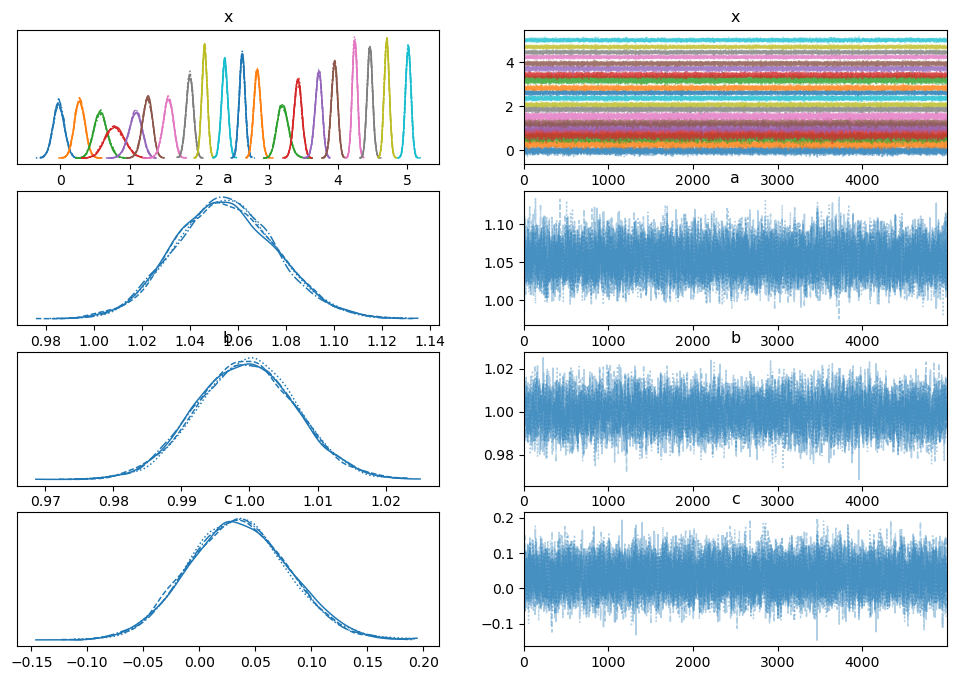

In [7]:
plt.suptitle("Progress of Chains (Trace) Plot", fontsize=15)
az.plot_trace(traces);

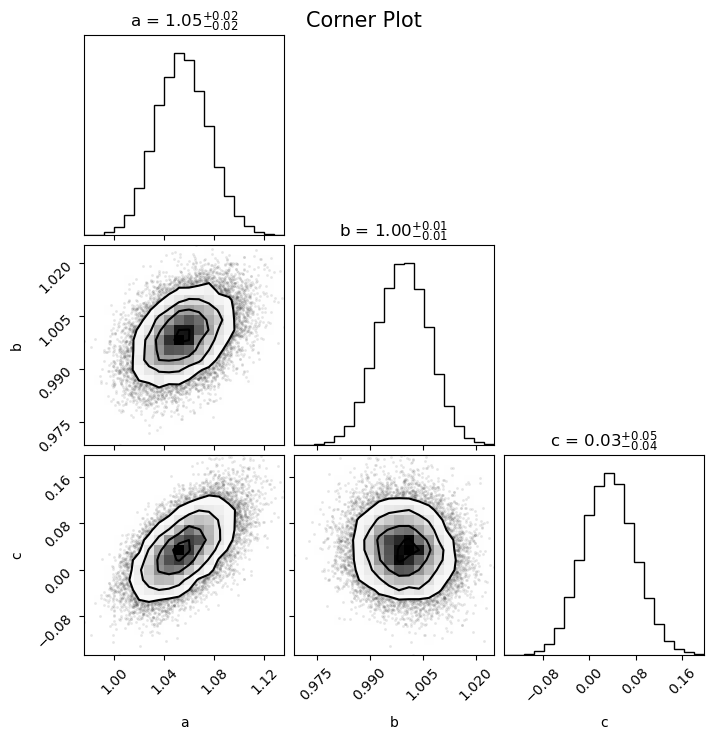

In [8]:
# extract posterior samples correctly
posterior = az.extract(
    traces,
    group="posterior",
    var_names=["a", "b", "c"]
)

samples = np.vstack([
    posterior["a"].values,
    posterior["b"].values,
    posterior["c"].values]).T

fig = corner.corner(
    samples,
    labels=['a', 'b', 'c'],
    show_titles=True,
    title_kwargs={"fontsize": 12}
)
fig.suptitle('Corner Plot', fontsize=15)
plt.show()

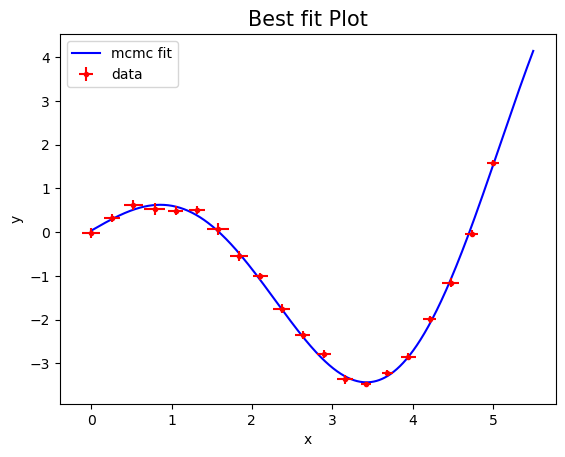

In [9]:
# let's take a look at the data and best-fit models 
x_grid = np.linspace(xObs.min()*1.1, xObs.max()*1.1, 1000)

# best fit here
y_fit = my_model_np(x_grid,
                float(bf["a"]),
                float(bf["b"]),
                float(bf["c"]))

# plot 
ax = plt.figure().add_subplot(111)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title('Best fit Plot', fontsize=15)
ax.plot(x_grid,y_fit, c='blue', label='mcmc fit')
ax.errorbar(xObs,yObs,xerr=xErr, yerr=yErr, color='r', marker='.', ls='None', label='data')
plt.legend()
plt.show() 

In [10]:
hdi_values = az.hdi(traces, hdi_prob=0.95)
print('95% Credible Intervals')
print('a:', hdi_values["a"].values)
print('b:', hdi_values["b"].values)
print('c:', hdi_values["c"].values)

95% Credible Intervals
a: [1.01432282 1.09506204]
b: [0.9853772  1.01360059]
c: [-0.05096476  0.12249253]


## Problem 2

Use **emcee** to fit two functions to the provided dataset (see below).

**Function 1:** 5-th order polynomial, $y(x) = \sum_{j=0}^5 c_j \, x^j$.

**Function 2:** $y(x) = A * x * np.cos(B*x) + C$. 

Show plots with
the progress of chains and the corner plots for both models, and a plot that shows data (with uncertainties for y axis) and both best fit models. Which model is a better description of provided data? How strong is the evidence? 

In [11]:
### this is the provided dataset to fit (note that x errors are assumed negligible): 
xObs = np.array([0.0, 0.26315789, 0.52631579, 0.78947368, 1.05263158, 1.31578947, 1.57894737, 1.84210526, 2.10526316, 2.36842105, 2.63157895, 2.89473684, 3.15789474, 3.42105263, 3.68421053, 3.94736842, 4.21052632, 4.47368421, 4.73684211, 5.0])
yObs = np.array([-0.01519999,  0.32530142,  0.62251935,  0.53022095,  0.49561467, 0.50552021,  0.07149746, -0.54528213, -1.01273784, -1.74602254, -2.34787813, -2.78038444, -3.36781022, -3.47795891, -3.21682447, -2.84510209, -1.99096649, -1.1576002 , -0.03944155,  1.57943597])
yErr = np.array([0.10993428, 0.09723471, 0.11295377, 0.1304606 , 0.09531693, 0.09531726, 0.13158426, 0.11534869, 0.09061051, 0.1108512, 0.09073165, 0.0906854 , 0.10483925, 0.0617344 , 0.06550164, 0.08875425, 0.07974338, 0.10628495, 0.08183952, 0.07175393])

In [12]:
# hints: 
# use these prior ranges for polynomial model parameters (Function 1)
thetaMinOne = (-1.0, -2.0, -2.0, -2.0, -2.0, -2.0)
thetaMaxOne = ( 1.0,  2.0,  2.0,  2.0,  2.0,  2.0)
# use these prior ranges for trigonometric model parameters (Function 2)
thetaMinTwo = (0.5,  0.5, -0.2)
thetaMaxTwo = (1.5,  1.5,  0.2)

In [13]:
# define models
def ModelOne(x, theta):
    return sum(c * (x**i) for i, c in enumerate(theta))

def ModelTwo(x, theta):
    A, B, C = theta
    return A * x * np.cos(B * x) + C

In [14]:
# Define our posterior using Python functions
# for clarity, I've separated-out the prior and likelihood
# but this is not necessary. Note that emcee requires log-posterior
LOGPRIOR_MIN = -np.inf 
# LOGPRIOR_MIN = -1.0e12

def log_flat_prior(theta, thetaMin, thetaMax):
    # logPriorMin = -np.inf  
    for k in range(np.size(theta)):
        if (theta[k]<thetaMin[k]): return LOGPRIOR_MIN 
        if (theta[k]>thetaMax[k]): return LOGPRIOR_MIN   
    return 1.0 
    
def log_prior(theta, thetaMin, thetaMax):
    return log_flat_prior(theta, thetaMin, thetaMax)

def log_likelihood_one(theta, x, y, yErr):
    # we are assuming that measurement errors are Gaussian and known
    # and thus ignoring normalization factors in the likelihood
    return -np.sum((y - ModelOne(x, theta)) ** 2 / yErr ** 2)

def log_posterior_one(theta, x, y, yErr, thetaMin, thetaMax):
    logLikelihood = log_likelihood_one(theta, x, y, yErr)
    logPrior = log_prior(theta, thetaMin, thetaMax)
    if logPrior > LOGPRIOR_MIN:
        return logPrior + logLikelihood
    else:
        return LOGPRIOR_MIN + logLikelihood

def log_likelihood_two(theta, x, y, yErr):
    # we are assuming that measurement errors are Gaussian and known
    # and thus ignoring normalization factors in the likelihood
    return -np.sum((y - ModelTwo(x, theta)) ** 2 / yErr ** 2)

def log_posterior_two(theta, x, y, yErr, thetaMin, thetaMax):
    logLikelihood = log_likelihood_two(theta, x, y, yErr)
    logPrior = log_prior(theta, thetaMin, thetaMax)
    if logPrior > LOGPRIOR_MIN:
        return logPrior + logLikelihood
    else:
        return LOGPRIOR_MIN + logLikelihood 

In [15]:
ndimOne = 6
ndimTwo = 3

nburn = 2000
nsteps = 10000
nwalkers = 100

np.random.seed(0)

# starting guesses for parameters \
def get_guesses(ndim, thetaMin, thetaMax, nwalkers=100):
    starting_guesses = 0.1*np.random.random((nwalkers, ndim))
    # set starting guesses at the center of flat priors
    for k in range(np.size(thetaMin)):
        starting_guesses[:,k] += 0.5*(thetaMin[k]+thetaMax[k])

    return starting_guesses

guessOne = get_guesses(ndimOne, thetaMinOne, thetaMaxOne)
guessTwo = get_guesses(ndimTwo, thetaMinTwo, thetaMaxTwo)

In [16]:
def get_sampler(ndim, log_posterior, args, guesses, nwalkers=100, nsteps=10000):
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=args)
    sampler.run_mcmc(initial_state=guesses, nsteps=nsteps) 
    print("done")
    return sampler

argsOne = [xObs, yObs, yErr, thetaMinOne, thetaMaxOne]
argsTwo = [xObs, yObs, yErr, thetaMinTwo, thetaMaxTwo]

samplerOne = get_sampler(ndimOne, log_posterior_one, argsOne, guessOne)
samplerTwo = get_sampler(ndimTwo, log_posterior_two, argsTwo, guessTwo)

done
done


In [17]:
print("Polynomial Fit:")
emcee_trace_one = samplerOne.chain[:, nburn:, :].reshape(-1, ndimOne).T
thetaFitOne= []
for k in range(ndimOne):
    thetaFitOne.append(np.median(emcee_trace_one[k]))
    print(f'dim {k} - - ', f'median: ', np.median(emcee_trace_one[k]),
          f'std: ', np.std(emcee_trace_one[k]), 'size: ', np.size(emcee_trace_one[k]))

print('Cosine Fit:')
emcee_trace_two = samplerTwo.chain[:, nburn:, :].reshape(-1, ndimTwo).T
thetaFitTwo= []
for k in range(ndimTwo):
    thetaFitTwo.append(np.median(emcee_trace_two[k]))
    print(f'dim {k} - - ', f'median: ', np.median(emcee_trace_two[k]),
          f'std: ', np.std(emcee_trace_two[k]), 'size: ', np.size(emcee_trace_two[k]))

Polynomial Fit:
dim 0 - -  median:  0.024222132195351694 std:  0.06948294747033015 size:  800000
dim 1 - -  median:  0.8825480610634482 std:  0.30207440036436517 size:  800000
dim 2 - -  median:  0.7196011497769745 std:  0.38636769380915886 size:  800000
dim 3 - -  median:  -1.3464059748702228 std:  0.19566871944715325 size:  800000
dim 4 - -  median:  0.39196196136736183 std:  0.042586046668651 size:  800000
dim 5 - -  median:  -0.031226357239385556 std:  0.0033291459977881624 size:  800000
Cosine Fit:
dim 0 - -  median:  1.049206025309338 std:  0.00920653623999322 size:  800000
dim 1 - -  median:  0.9981822079293894 std:  0.0014856774521682472 size:  800000
dim 2 - -  median:  0.050013828467688225 std:  0.021780735831470308 size:  800000


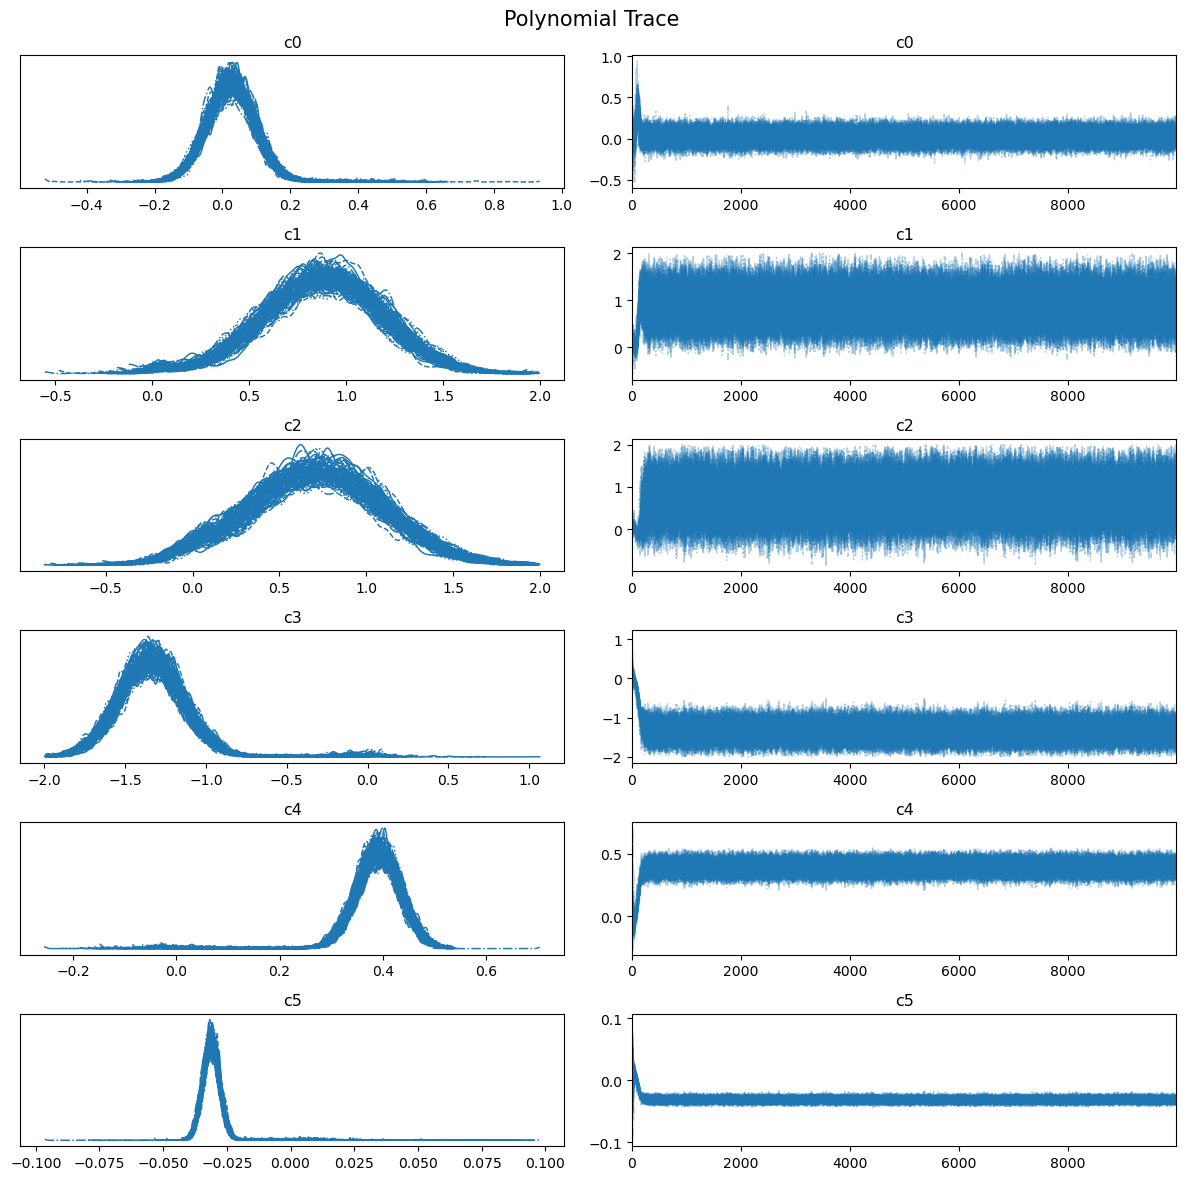

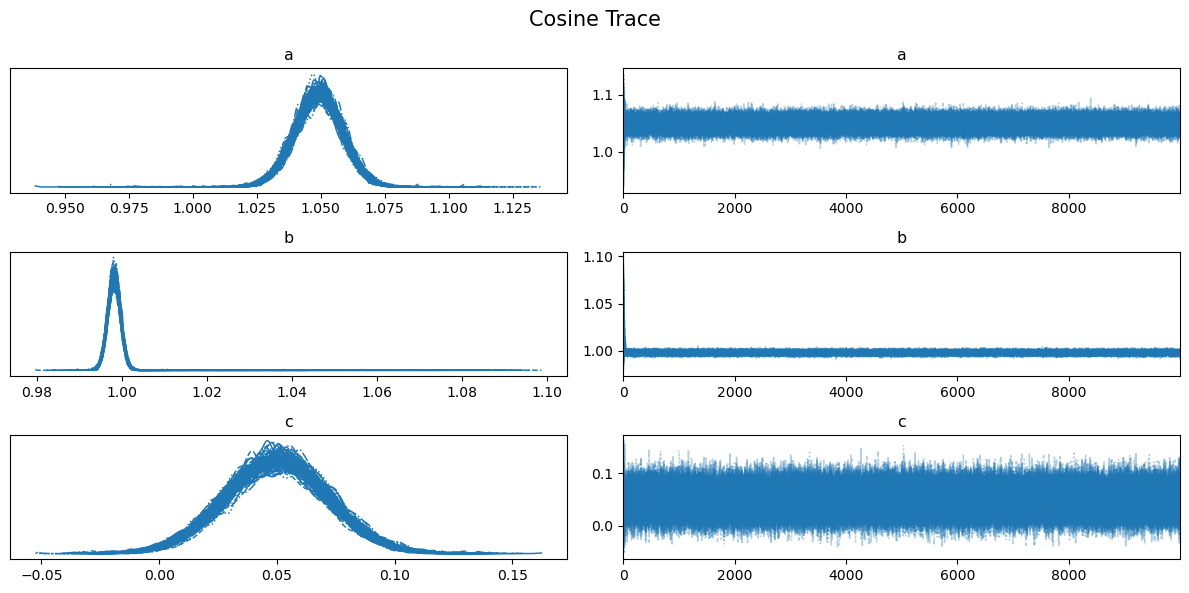

In [18]:
idataOne = az.from_emcee(samplerOne, var_names=['c0', 'c1', 'c2', 'c3', 'c4', 'c5']);
az.plot_trace(idataOne);
plt.suptitle("Polynomial Trace", fontsize=15);
plt.tight_layout()

idataTwo = az.from_emcee(samplerTwo, var_names=['a', 'b', 'c']);
az.plot_trace(idataTwo);
plt.suptitle("Cosine Trace", fontsize=15);
plt.tight_layout()

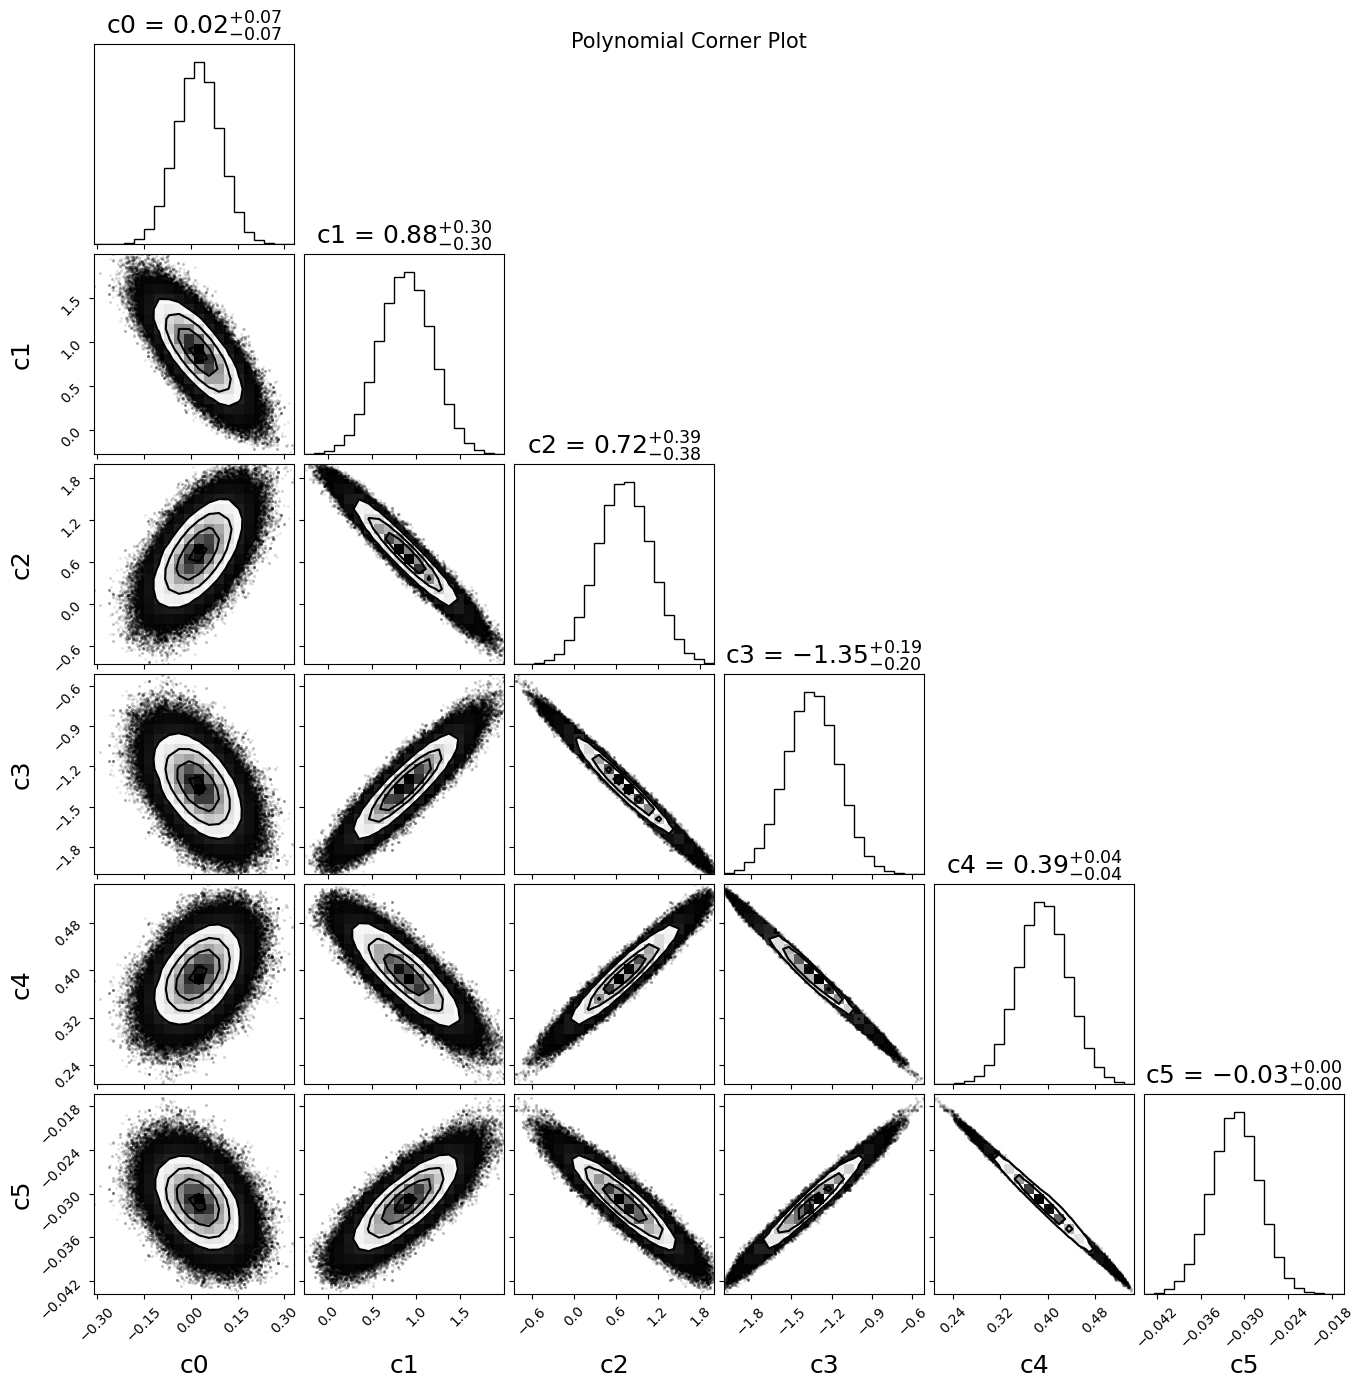

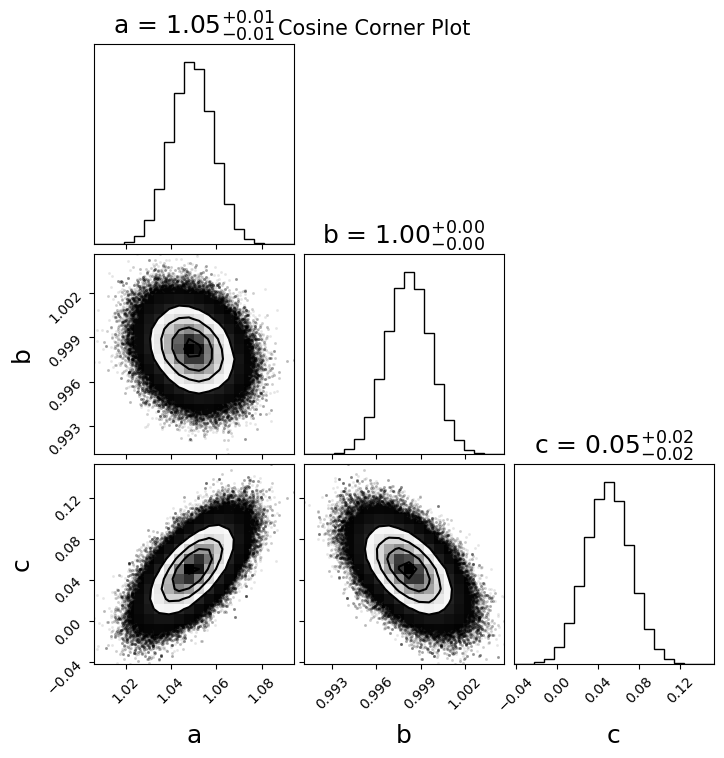

In [19]:
samples = np.vstack([emcee_trace_one[k] for k in range(0,ndimOne)]).T
Ls = ['c0', 'c1', 'c2', 'c3', 'c4', 'c5']

fig = corner.corner(
    samples, 
    bins=20,
    labels=Ls, 
    label_kwargs={"fontsize": 18}, 
    tick_kwargs={"fontsize": 38}, 
    show_titles=True, 
    title_kwargs={"fontsize": 18}
)
fig.suptitle("Polynomial Corner Plot", fontsize=15)  
plt.show()

samples = np.vstack([emcee_trace_two[k] for k in range(0,ndimTwo)]).T
Ls = ['a', 'b', 'c'] 

fig = corner.corner(
    samples, 
    bins=20,
    labels=Ls, 
    label_kwargs={"fontsize": 18}, 
    tick_kwargs={"fontsize": 38}, 
    show_titles=True, 
    title_kwargs={"fontsize": 18}
) 
fig.suptitle("Cosine Corner Plot", fontsize=15)  
plt.show()

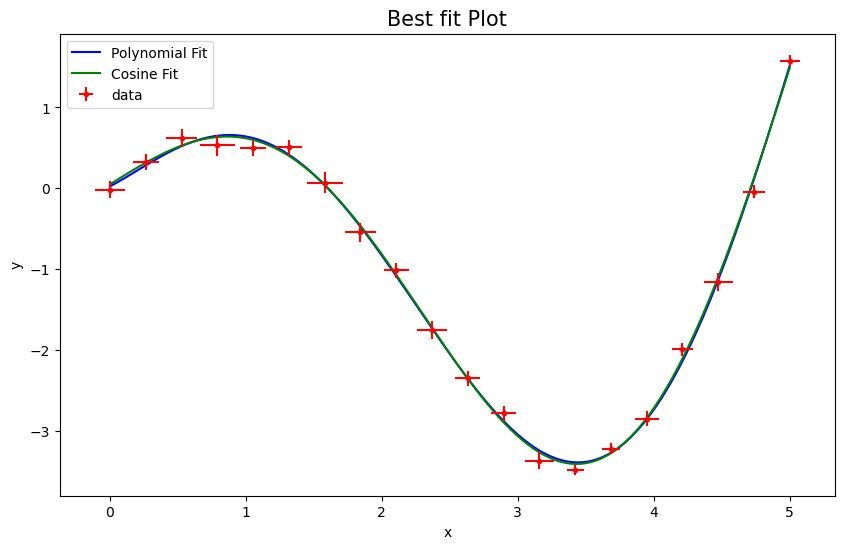

In [20]:
# Plot input data
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)

# Plot the model fit
xfit = np.linspace(min(xObs), max(xObs), 500)
yfitOne = ModelOne(xfit, thetaFitOne)
ax.plot(xfit, yfitOne, c='b', label="Polynomial Fit")
yfitTwo = ModelTwo(xfit, thetaFitTwo)
ax.plot(xfit, yfitTwo, c='g', label="Cosine Fit")

# plot 
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title('Best fit Plot', fontsize=15)
ax.errorbar(xObs, yObs, xerr=xErr, yerr=yErr, color='r', marker='.', ls='None', label='data')
ax.legend()
plt.show()

In [21]:
## let's evaluate chi2 and BIC
yfitOne = ModelOne(xObs, thetaFitOne)
chi2One = np.sum(((yObs-yfitOne)/yErr)**2) 
BIC_one = chi2One + ndimOne *np.log(np.size(xObs))

yfitTwo = ModelTwo(xObs, thetaFitTwo)
chi2Two = np.sum(((yObs-yfitTwo)/yErr)**2) 
BIC_two = chi2Two + ndimTwo *np.log(np.size(xObs))

In [22]:
print ("             MODEL                   CHI2            BIC")
print ('    best polynomial model:', chi2One, BIC_one)
print ('    best cosine model:', chi2Two, BIC_two)

             MODEL                   CHI2            BIC
    best polynomial model: 18.714808002165267 36.68920164348921
    best cosine model: 17.719156004498196 26.706352825160167


Since the BIC of the cosine fit is around 10 less than that of the polynomial fit, there is very strong evidence that the cosine fit is a better description of the data. This makes sense as the chi2 values are similar, but the cosine model has half the parameters of the polynomial.

## Problem 3

### you need astroML! 

Apply Bayesian Blocks Algorithm to period distribution of LINEAR variable stars (see below) and
compare the result to classical (Knuth's) uniform bin width histogram.
Plot histograms on both linear and log scale. 

In [23]:
# fetch data
from astroML.datasets import fetch_LINEAR_geneva
data = fetch_LINEAR_geneva()
xN = data['logP']
N = xN.size
print('read LINEAR dataset: N =', N)

read LINEAR dataset: N = 6146


c:\Users\harty\miniconda3\envs\standard\Lib\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


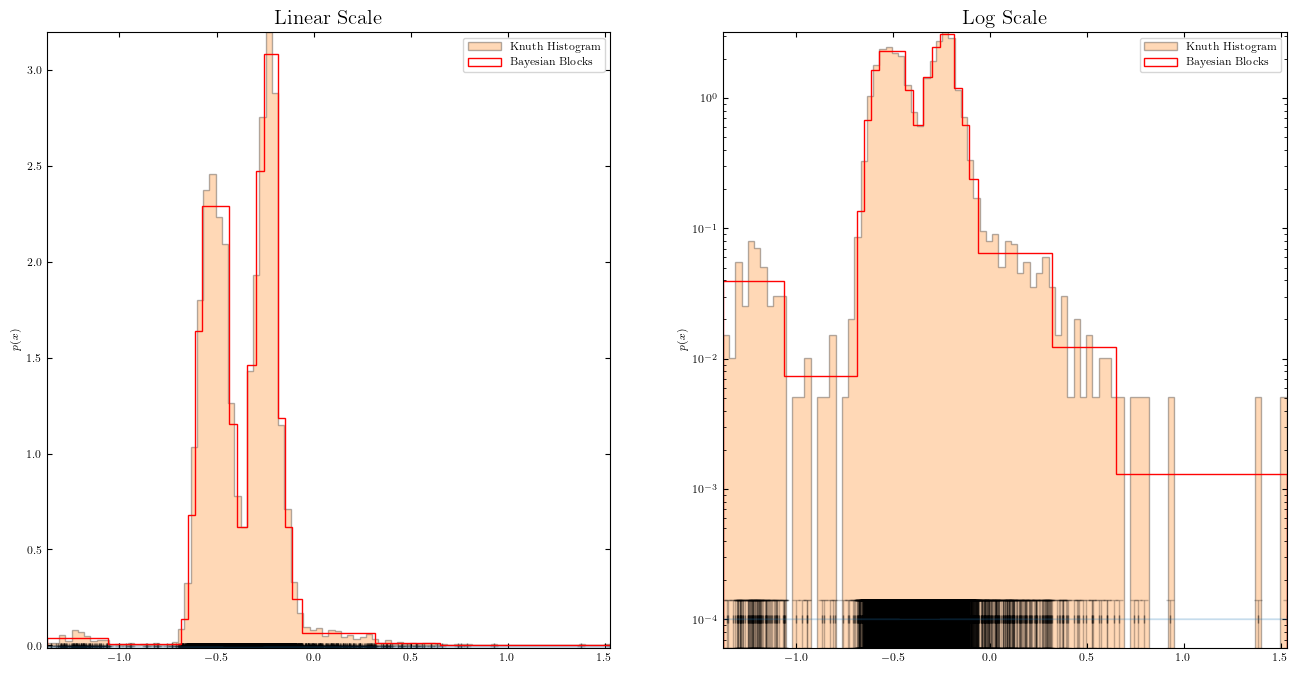

In [24]:
from scipy import stats
from astropy.visualization import hist
np.random.seed(42)
from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=True)

#------------------------------------------------------------
fig = plt.figure(figsize=(16,8))

# plot the results - linear
ax1 = fig.add_subplot(121)

ax1.errorbar(xN, -0.01 + 0*xN, xerr=0.0, yerr=0.005, ecolor='black', lw=1, alpha=0.25)

hist(xN, bins='knuth', ax=ax1, density=True,
        histtype='stepfilled', alpha=0.3,
        label='Knuth Histogram')

hist(xN, bins='blocks', ax=ax1, density=True,
        histtype='step', color='red', alpha=0.99,
        label="Bayesian Blocks")

# label the plot
ax1.set_ylabel('$p(x)$')
ax1.set_title('Linear Scale', fontsize=15)
ax1.legend()

# plot the results - logscale
ax2 = fig.add_subplot(122)

# plot the results
ax2.errorbar(xN, 1e-4 + 0*xN, xerr=0.0, yerr=4e-5, ecolor='black', lw=1, alpha=0.25)

hist(xN, bins='knuth', ax=ax2, density=True,
        histtype='stepfilled', alpha=0.3,
        label='Knuth Histogram')

hist(xN, bins='blocks', ax=ax2, density=True,
        histtype='step', color='red', alpha=0.99,
        label="Bayesian Blocks")

ax2.set_yscale('log')

# label the plot
ax2.set_ylabel('$p(x)$')
ax2.set_title('Log Scale', fontsize=15)
ax2.legend()

plt.show()

## Problem 4

These questions are similar to those that you will be asked on the final exam. Please answer each one with 1-3 sentences. 

* What does Markov Chain Monte Carlo method do?  

It solves complicated probability problems by making many 'guesses' that are informed by priors. It returns a sample of points, or chain, whose distribution is asymptotically proportional to the pdf.

* What can Metropolis-Hastings algorithm do? 

The Metropolis-Hastings algorithm is a MCMC algorithm that is used to grab the sample of points discussed above. It ensures that you will reach a stationary distribution and that it will approximate a sample drawn from p(theta).

* What is Bayesian Blocks algorithm useful for? How is it different from Knuth's histogram?

They are different because Knuth's assumes a constant bin width, while Bayesian blocks allows the bin width to vary based on the density of data points. This allows the histogram to handle outliers / noise by placing them in wide bins, but pick up on finer details when the density of points is high.